1. Load processed dataset
2. Remove unnecessary columns
3. Separate features (X) and target (y)
4. Train/Test Split
5. Create target-based features (without data leakage)
6. Encode categorical variables
7. Handle class imbalance (SMOTE)
8. Train baseline model
9. Evaluate
10. Improve the model


In [318]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/upi_fraud_feature_engineered.csv")


In [319]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   transaction id          250000 non-null  str  
 1   timestamp               250000 non-null  str  
 2   transaction type        250000 non-null  str  
 3   merchant_category       250000 non-null  str  
 4   amount (INR)            250000 non-null  int64
 5   transaction_status      250000 non-null  str  
 6   sender_age_group        250000 non-null  str  
 7   receiver_age_group      250000 non-null  str  
 8   sender_state            250000 non-null  str  
 9   sender_bank             250000 non-null  str  
 10  receiver_bank           250000 non-null  str  
 11  device_type             250000 non-null  str  
 12  network_type            250000 non-null  str  
 13  fraud_flag              250000 non-null  int64
 14  transaction_hour        250000 non-null  int64
 15  day_of_week

In [320]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,4G,0,15,Tuesday,0,0,0,0,0,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,4G,0,6,Thursday,0,0,0,1,0,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,4G,0,13,Tuesday,0,0,0,0,0,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,5G,0,10,Sunday,1,0,0,1,0,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [321]:
df = df.drop(columns=["transaction id", "timestamp" ])

In [322]:
df.head()

,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0,0,0,0,0
1,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0,0,1,0,0
2,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0,0,0,0,0
3,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0,0,1,0,1
4,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [323]:
df["transaction_status"].value_counts()

transaction_status
SUCCESS    237624
FAILED      12376
Name: count, dtype: int64

In [324]:
pd.crosstab(
    df["transaction_status"],
    df["fraud_flag"],
    normalize = "index"
)*100

fraud_flag,0,1
transaction_status,,
FAILED,99.830317,0.169683
SUCCESS,99.806838,0.193162


In [325]:
df = df.drop(columns=["transaction_status"])

In [326]:
df.head()

,transaction type,merchant_category,amount (INR),sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,P2P,Entertainment,868,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0,0,0,0,0
1,P2M,Grocery,1011,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0,0,1,0,0
2,P2P,Grocery,477,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0,0,0,0,0
3,P2P,Fuel,2784,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0,0,1,0,1
4,P2P,Shopping,990,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [327]:
X = df.drop(columns="fraud_flag")
y = df["fraud_flag"]

In [328]:
print(X.shape)
print(y.shape)

(250000, 18)
(250000,)


In [329]:
from sklearn.model_selection import train_test_split

In [330]:
X_train,X_test,y_train,y_test = train_test_split (
    X,
    y,
    test_size=0.2,random_state = 42,stratify = y
)

In [331]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(200000, 18)
(50000, 18)
(200000,)
(50000,)


In [332]:
y_train.value_counts(normalize=True)


fraud_flag
0    0.99808
1    0.00192
Name: proportion, dtype: float64

In [333]:
y_test.value_counts(normalize=True)

fraud_flag
0    0.99808
1    0.00192
Name: proportion, dtype: float64

In [334]:
print("Original Dataset")
print(y.value_counts(normalize=True))

print("\nTraining Set")
print(y_train.value_counts(normalize=True))

print("\nTesting Set")
print(y_test.value_counts(normalize=True))

Original Dataset
fraud_flag
0    0.99808
1    0.00192
Name: proportion, dtype: float64

Training Set
fraud_flag
0    0.99808
1    0.00192
Name: proportion, dtype: float64

Testing Set
fraud_flag
0    0.99808
1    0.00192
Name: proportion, dtype: float64


In [335]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   transaction type        250000 non-null  str  
 1   merchant_category       250000 non-null  str  
 2   amount (INR)            250000 non-null  int64
 3   sender_age_group        250000 non-null  str  
 4   receiver_age_group      250000 non-null  str  
 5   sender_state            250000 non-null  str  
 6   sender_bank             250000 non-null  str  
 7   receiver_bank           250000 non-null  str  
 8   device_type             250000 non-null  str  
 9   network_type            250000 non-null  str  
 10  fraud_flag              250000 non-null  int64
 11  transaction_hour        250000 non-null  int64
 12  day_of_week             250000 non-null  str  
 13  is_weekend              250000 non-null  int64
 14  night_transaction       250000 non-null  int64
 15  same_bank  

We will use oneHot encoding

In [336]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [337]:
categorical_columns = X_train.select_dtypes(include = ["object","str"]).columns.tolist()
categorical_columns
numericl_columns = ["amount (INR)","transaction_hour"]
binary_columns = [
    "is_weekend",
    "night_transaction",
    "same_bank",
    "same_age_group",
    "high_value_transaction",
    "peak_hour" 
]

In [338]:
df.head()

,transaction type,merchant_category,amount (INR),sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,P2P,Entertainment,868,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0,0,0,0,0
1,P2M,Grocery,1011,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0,0,1,0,0
2,P2P,Grocery,477,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0,0,0,0,0
3,P2P,Fuel,2784,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0,0,1,0,1
4,P2P,Shopping,990,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [339]:
print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numericl_columns)

print("\nBinary columns:")
print(binary_columns)

print("\nTotal raw features:")
print(
    len(categorical_columns)
    + len(numericl_columns)
    + len(binary_columns)
)

Categorical columns:
['transaction type', 'merchant_category', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']

Numeric columns:
['amount (INR)', 'transaction_hour']

Binary columns:
['is_weekend', 'night_transaction', 'same_bank', 'same_age_group', 'high_value_transaction', 'peak_hour']

Total raw features:
18


In [340]:
from sklearn.preprocessing import StandardScaler


preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop = "first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            "numerical",
            StandardScaler(),
            numericl_columns
        ),
        (
            "Binary",
            "passthrough",
            binary_columns
        )
    ]
)

In [341]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

In [342]:
prepared_feature_names = preprocessor.get_feature_names_out()
prepared_feature_names

array(['categorical__transaction type_P2M',
       'categorical__transaction type_P2P',
       'categorical__transaction type_Recharge',
       'categorical__merchant_category_Entertainment',
       'categorical__merchant_category_Food',
       'categorical__merchant_category_Fuel',
       'categorical__merchant_category_Grocery',
       'categorical__merchant_category_Healthcare',
       'categorical__merchant_category_Other',
       'categorical__merchant_category_Shopping',
       'categorical__merchant_category_Transport',
       'categorical__merchant_category_Utilities',
       'categorical__sender_age_group_26-35',
       'categorical__sender_age_group_36-45',
       'categorical__sender_age_group_46-55',
       'categorical__sender_age_group_56+',
       'categorical__receiver_age_group_26-35',
       'categorical__receiver_age_group_36-45',
       'categorical__receiver_age_group_46-55',
       'categorical__receiver_age_group_56+',
       'categorical__sender_state_Delhi',
  

In [343]:
print(X_train_prepared.shape)

(200000, 62)


In [344]:
X_train_prepared = pd.DataFrame(
    X_train_prepared,
    columns = prepared_feature_names,
    index= X_train.index
)
X_test_prepared= pd.DataFrame(
    X_test_prepared,
    columns = prepared_feature_names,
    index = X_test.index

)

In [345]:
X_train_prepared[
    [
        "numerical__amount (INR)",
        "numerical__transaction_hour"
    ]
].describe()

,numerical__amount (INR),numerical__transaction_hour
count,2.000000e+05,2.000000e+05
mean,-3.751666e-17,-1.511324e-16
std,1.000003e+00,1.000003e+00
min,-7.039200e-01,-2.830949e+00
25%,-5.537172e-01,-7.114972e-01
50%,-3.694756e-01,5.921268e-02
75%,1.529924e-01,8.299225e-01
max,2.203668e+01,1.600632e+00


Building the Model

In [346]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

model.fit(X_train_prepared, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [347]:
print("Iterations used:", model.n_iter_)

Iterations used: [41]


In [348]:
y_pred = model.predict(X_test_prepared)

In [349]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print(f"Acuracy: {accuracy:.4f}")

Acuracy: 0.5957


In [350]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[29741 20163]
 [   54    42]]


In [351]:
from sklearn.metrics import classification_report

In [352]:
print(classification_report(y_test,y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.9982    0.5960    0.7463     49904
           1     0.0021    0.4375    0.0041        96

    accuracy                         0.5957     50000
   macro avg     0.5001    0.5167    0.3752     50000
weighted avg     0.9963    0.5957    0.7449     50000



In [353]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[29741 20163]
 [   54    42]]


In [354]:
print(y_pred[:20])

[0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0]


In [355]:
import numpy as np
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([29795, 20205]))


## Training the Random Forest Model

In [356]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs = -1
)

random_forest_model.fit(X_train_prepared,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [357]:
y_pred_rf = random_forest_model.predict(X_test_prepared)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(50000,))

In [358]:
#Evaluating the Random forest model
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Random forest Accuracy:")
print(accuracy_score(y_test,y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=5))


Random forest Accuracy:
0.99808

Random Forest Confusion Matrix:
[[49904     0]
 [   96     0]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0    0.99808   1.00000   0.99904     49904
           1    0.00000   0.00000   0.00000        96

    accuracy                        0.99808     50000
   macro avg    0.49904   0.50000   0.49952     50000
weighted avg    0.99616   0.99808   0.99712     50000



e:\Projects\UPI Fraud detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Projects\UPI Fraud detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Projects\UPI Fraud detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [359]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=5,
        zero_division=0
    )
)

Random Forest Accuracy:
0.99808

Random Forest Confusion Matrix:
[[49904     0]
 [   96     0]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0    0.99808   1.00000   0.99904     49904
           1    0.00000   0.00000   0.00000        96

    accuracy                        0.99808     50000
   macro avg    0.49904   0.50000   0.49952     50000
weighted avg    0.99616   0.99808   0.99712     50000



In [360]:
fraud_prob_rf = random_forest_model.predict_proba(X_test_prepared)[:,1]

print("Minimum probability:", fraud_prob_rf.min())
print("Maximum probability:", fraud_prob_rf.max())
print("Average probability:", fraud_prob_rf.mean())

Minimum probability: 0.0
Maximum probability: 0.27
Average probability: 0.0050724


In [361]:
pd.Series(fraud_prob_rf).sort_values(ascending=False).head(20)

16227    0.270
2467     0.265
26572    0.255
28165    0.215
25810    0.195
34182    0.195
7421     0.195
43704    0.190
11858    0.190
5582     0.190
7422     0.180
40572    0.175
44754    0.175
11284    0.170
42870    0.165
32373    0.160
1470     0.155
22211    0.145
28081    0.145
47150    0.140
dtype: float64

## Training the XGboost model

In [362]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Genuine training transactions:", negative_count)
print("Fraud training transactions:", positive_count)
print("Scale pos weight:", scale_pos_weight)

Genuine training transactions: 199616
Fraud training transactions: 384
Scale pos weight: 519.8333333333334


In [363]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train_prepared, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [364]:
y_pred_xgb = xgb_model.predict(X_test_prepared)

In [365]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("XGBoost Accuracy:")
print(accuracy_score(y_test, y_pred_xgb))

print("\nXGBoost Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nXGBoost Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=5,
        zero_division=0
    )
)

XGBoost Accuracy:
0.8033

XGBoost Confusion Matrix:
[[40149  9755]
 [   80    16]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0    0.99801   0.80452   0.89088     49904
           1    0.00164   0.16667   0.00324        96

    accuracy                        0.80330     50000
   macro avg    0.49982   0.48560   0.44706     50000
weighted avg    0.99610   0.80330   0.88918     50000



In [366]:
fraud_prob_xgb = xgb_model.predict_proba(X_test_prepared)[:, 1]

print("Minimum probability:", fraud_prob_xgb.min())
print("Maximum probability:", fraud_prob_xgb.max())
print("Average probability:", fraud_prob_xgb.mean())

Minimum probability: 0.005005062
Maximum probability: 0.85410106
Average probability: 0.37314233


In [367]:
from sklearn.metrics import(
    average_precision_score,
    roc_auc_score
)

#Logistic Regression Probabilities
fraud_prob_lr = model.predict_proba(X_test_prepared)[:,1]

print("rf= ", fraud_prob_rf)

print("rf= ", fraud_prob_xgb)

print("Logistic Regression")
print("PR-AUC:", average_precision_score(y_test, fraud_prob_lr))
print("ROC-AUC:", roc_auc_score(y_test, fraud_prob_lr))

print("\nRandom Forest")
print("PR-AUC:", average_precision_score(y_test, fraud_prob_rf))
print("ROC-AUC:", roc_auc_score(y_test, fraud_prob_rf))

print("\nXGBoost")
print("PR-AUC:", average_precision_score(y_test, fraud_prob_xgb))
print("ROC-AUC:", roc_auc_score(y_test, fraud_prob_xgb))

rf=  [0.005 0.    0.005 ... 0.005 0.    0.   ]
rf=  [0.4201225  0.3139033  0.42642632 ... 0.47963566 0.51860446 0.54137254]
Logistic Regression
PR-AUC: 0.0018623502170730458
ROC-AUC: 0.5035582902506145

Random Forest
PR-AUC: 0.003172845886888875
ROC-AUC: 0.5582898331463075

XGBoost
PR-AUC: 0.0017705946323044784
ROC-AUC: 0.475554523017527


Applying SMOTE TO SEE IF PERFORMANCE INCREASES

In [368]:
from imblearn.over_sampling import SMOTE

In [369]:
import sys
print(sys.executable)

e:\Projects\UPI Fraud detection\.venv\Scripts\python.exe


In [370]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "imbalanced-learn"
])

0

In [371]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully")

SMOTE imported successfully


In [372]:
import sys

!"{sys.executable}" -m pip show imbalanced-learn

Name: imbalanced-learn
Version: 0.14.2
Summary: Toolbox for imbalanced dataset in machine learning
Home-page: 
Author: 
Author-email: "G. Lemaitre" <g.lemaitre58@gmail.com>, "C. Aridas" <ichkoar@gmail.com>
License: 
Location: e:\Projects\UPI Fraud detection\.venv\Lib\site-packages
Requires: joblib, numpy, scikit-learn, scipy, sklearn-compat, threadpoolctl
Required-by: 


In [373]:
smote = SMOTE(random_state =42)

In [374]:
X_train_smote,y_train_smote = smote.fit_resample(
    X_train_prepared,
    y_train
)

In [375]:
print(y_train.value_counts())
print()
print(y_train_smote.value_counts())

fraud_flag
0    199616
1       384
Name: count, dtype: int64

fraud_flag
0    199616
1    199616
Name: count, dtype: int64


Training Logistic regression on SMOTE data

In [376]:
from sklearn.linear_model import LogisticRegression
lr_smote = LogisticRegression(
    random_state = 42,
    max_iter=1000,
    
)

lr_smote.fit(X_train_smote,y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [377]:
y_pred_lr_smote = lr_smote.predict(X_test_prepared)

In [378]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression + SMOTE")

print("Accuracy:")
print(accuracy_score(y_test, y_pred_lr_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_smote))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr_smote,
        digits=5,
        zero_division=0
    )
)

Logistic Regression + SMOTE
Accuracy:
0.59106

Confusion Matrix:
[[29518 20386]
 [   61    35]]

Classification Report:
              precision    recall  f1-score   support

           0    0.99794   0.59150   0.74275     49904
           1    0.00171   0.36458   0.00341        96

    accuracy                        0.59106     50000
   macro avg    0.49983   0.47804   0.37308     50000
weighted avg    0.99602   0.59106   0.74133     50000



Training Random folrest model

In [379]:
from sklearn.ensemble import RandomForestClassifier
rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote,y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [380]:
y_pred_rf_smote = rf_smote.predict(X_test_prepared)

In [381]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

fraud_prob_rf_smote = rf_smote.predict_proba(X_test_prepared)[:, 1]

print("Random Forest + SMOTE")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_rf_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf_smote,
        digits=5,
        zero_division=0
    )
)

print("\nPR-AUC:")
print(average_precision_score(y_test, fraud_prob_rf_smote))

print("\nROC-AUC:")
print(roc_auc_score(y_test, fraud_prob_rf_smote))

Random Forest + SMOTE

Accuracy:
0.99808

Confusion Matrix:
[[49904     0]
 [   96     0]]

Classification Report:
              precision    recall  f1-score   support

           0    0.99808   1.00000   0.99904     49904
           1    0.00000   0.00000   0.00000        96

    accuracy                        0.99808     50000
   macro avg    0.49904   0.50000   0.49952     50000
weighted avg    0.99616   0.99808   0.99712     50000


PR-AUC:
0.003292012739609945

ROC-AUC:
0.530008240822379


Train XGB model

In [382]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_smote.fit(X_train_smote, y_train_smote)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [383]:
y_pred_xgb_smote = xgb_smote.predict(X_test_prepared)

In [384]:
fraud_prob_xgb_smote = xgb_smote.predict_proba(
    X_test_prepared
)[:, 1]

print("XGBoost + SMOTE")

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_xgb_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_smote))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_smote,
        digits=5,
        zero_division=0
    )
)

print("\nPR-AUC:")
print(average_precision_score(y_test, fraud_prob_xgb_smote))

print("\nROC-AUC:")
print(roc_auc_score(y_test, fraud_prob_xgb_smote))

XGBoost + SMOTE

Accuracy:
0.99808

Confusion Matrix:
[[49904     0]
 [   96     0]]

Classification Report:
              precision    recall  f1-score   support

           0    0.99808   1.00000   0.99904     49904
           1    0.00000   0.00000   0.00000        96

    accuracy                        0.99808     50000
   macro avg    0.49904   0.50000   0.49952     50000
weighted avg    0.99616   0.99808   0.99712     50000


PR-AUC:
0.0018182601469382924

ROC-AUC:
0.4960388529309607


In [385]:
print(X_train_smote.shape)
print(y_train_smote.shape)

(399232, 62)
(399232,)


In [386]:
print(X_train_prepared.shape)
print(y_train.shape)

(200000, 62)
(200000,)


In [387]:
pd.Series(y_pred_xgb_smote).value_counts()


0    50000
Name: count, dtype: int64

In [388]:
pd.Series(y_pred_rf_smote).value_counts()

0    50000
Name: count, dtype: int64

In [389]:
fraud_prob_xgb_smote = xgb_smote.predict_proba(X_test_prepared)[:, 1]

print("Minimum:", fraud_prob_xgb_smote.min())
print("Maximum:", fraud_prob_xgb_smote.max())
print("Average:", fraud_prob_xgb_smote.mean())

Minimum: 0.0036960333
Maximum: 0.3431947
Average: 0.069571175


In [390]:
# import pandas as pd

# df = pd.read_csv(
#     "../data/processed/upi_fraud_feature_engineered_v2.csv"
# )

In [391]:
# df.shape

In [392]:
# df.columns

In [393]:
# df = df.drop(
#     columns=[
#         "transaction id",
#         "timestamp",
#         "transaction_status"
#     ]
# )

In [394]:
# X_log = df.drop(columns="fraud_flag")
# y_log = df["fraud_flag"]

In [395]:
# print(X_log.shape)
# print(y_log.shape)

In [396]:
# from sklearn.model_selection import train_test_split

# X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
#     X_log,
#     y_log,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_log
# )

In [397]:
# print("Train shape:", X_train_log.shape)
# print("Test shape:", X_test_log.shape)

# print("\nTraining distribution:")
# print(y_train_log.value_counts())

# print("\nTesting distribution:")
# print(y_test_log.value_counts())

In [398]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder

In [399]:
# df.select_dtypes(include="number")

In [400]:
# categorical_columns = X_train_log.select_dtypes(include = ["object","str"]).columns.tolist()
# categorical_columns
# numericl_columns = ["amount (INR)","transaction_hour","amount_log","hour_sin","hour_cos","day_sin","day_cos"]
# binary_columns = [
#     "is_weekend",
#     "night_transaction",
#     "same_bank",
#     "same_age_group",
#     "high_value_transaction",
#     "peak_hour" 
# ]

In [401]:
# from sklearn.preprocessing import StandardScaler


# preprocessor2 = ColumnTransformer(
#     transformers=[
#         (
#             "categorical",
#             OneHotEncoder(
#                 drop = "first",
#                 handle_unknown="ignore",
#                 sparse_output=False
#             ),
#             categorical_columns
#         ),
#         (
#             "numerical",
#             StandardScaler(),
#             numericl_columns
#         ),
#         (
#             "Binary",
#             "passthrough",
#             binary_columns
#         )
#     ]
# )

In [402]:
# X_train_log_prepared = preprocessor.fit_transform(X_train_log)
# X_test__log_prepared = preprocessor.transform(X_test_log)

In [403]:
# prepared_feature_names = preprocessor.get_feature_names_out()
# prepared_feature_names

In [404]:
# df.head()

In [405]:
# from sklearn.linear_model import LogisticRegression

# log_lr_model = LogisticRegression(
#     class_weight="balanced",
#     random_state=42,
#     max_iter=2000
# )

# log_lr_model.fit(X_train_log_prepared, y_train_log)

In [406]:
# y_log_pred_lr = log_lr_model.predict(X_test__log_prepared)

In [407]:
# from sklearn.metrics import (
#     accuracy_score,
#     confusion_matrix,
#     classification_report
# )

# print("Logistic Regression + log features")

# print("Accuracy:")
# print(accuracy_score(y_test_log, y_log_pred_lr))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_log, y_log_pred_lr))

# print("\nClassification Report:")
# print(
#     classification_report(
#         y_test_log,
#         y_log_pred_lr,
#         digits=5,
#         zero_division=0
#     )
# )

In [408]:
# from sklearn.ensemble import RandomForestClassifier
# rf_log = RandomForestClassifier(
#     n_estimators=200,
#     random_state=42,
#     n_jobs=-1
# )

# rf_log.fit(X_train_log_prepared,y_train_log)

In [409]:
# y_log_pred_rf = rf_log.predict(X_test__log_prepared)


In [410]:
# from sklearn.metrics import (
#     accuracy_score,
#     confusion_matrix,
#     classification_report,
#     average_precision_score,
#     roc_auc_score
# )

# fraud_prob_log_rf = rf_log.predict_proba(X_test__log_prepared)[:, 1]

# print("Random Forest + LOG")

# print("\nAccuracy:")
# print(accuracy_score(y_test_log, y_log_pred_rf))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test_log, y_log_pred_rf))

# print("\nClassification Report:")
# print(
#     classification_report(
#         y_test_log,
#         y_log_pred_rf,
#         digits=5,
#         zero_division=0
#     )
# )

# print("\nPR-AUC:")
# print(average_precision_score(y_test_log, fraud_prob_log_rf))

# print("\nROC-AUC:")
# print(roc_auc_score(y_test_log, fraud_prob_log_rf))

## Hyper parameter tuning of base Logistic regression model

In [411]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [412]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

In [413]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=1,
    verbose=1
)

In [414]:
grid_search.fit(
    X_train_prepared,
    y_train
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see

In [415]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Average Precision:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}

Best CV Average Precision:
0.002204884790072034


In [416]:
best_log_model = grid_search.best_estimator_
best_log_model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalti

In [417]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_train_prob = cross_val_predict(
    best_log_model,
    X_train_prepared,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [418]:
print("Minimum probability:", y_train_prob.min())
print("Maximum probability:", y_train_prob.max())
print("Average probability:", y_train_prob.mean())

Minimum probability: 0.12044138940796338
Maximum probability: 0.9091641274788238
Average probability: 0.4743037069634567


In [419]:
print(y_train_prob[:20])

[0.49093755 0.37385881 0.48364747 0.36230711 0.41425545 0.6373899
 0.376406   0.40134478 0.72659353 0.48614128 0.37049441 0.67232887
 0.56814262 0.4063208  0.52933654 0.35208391 0.44859937 0.4328826
 0.47390225 0.42679373]


In [420]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:

    y_pred_threshold = (y_train_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold
    )

    results.append([
        threshold,
        tn,
        fp,
        fn,
        tp,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_results

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
0,0.3,11016,188600,17,367,0.001942,0.955729,0.003876
1,0.4,51579,148037,93,291,0.001962,0.757812,0.003914
2,0.5,118829,80787,204,180,0.002223,0.468750,0.004425
3,0.6,173320,26296,319,65,0.002466,0.169271,0.004861
4,0.7,195170,4446,374,10,0.002244,0.026042,0.004132
5,0.8,199357,259,384,0,0.000000,0.000000,0.000000


In [421]:
import numpy as np

thresholds = np.arange(0.50, 0.66, 0.01)

In [422]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


results = []

for threshold in thresholds:

    y_pred_threshold = (y_train_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold
    )

    results.append([
        threshold,
        tn,
        fp,
        fn,
        tp,
        precision,
        recall,
        f1
    ])

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_results

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
0,0.50,118829,80787,204,180,0.002223,0.468750,0.004425
1,0.51,125576,74040,222,162,0.002183,0.421875,0.004344
2,0.52,132151,67465,236,148,0.002189,0.385417,0.004353
3,0.53,138355,61261,249,135,0.002199,0.351562,0.004370
4,0.54,144431,55185,260,124,0.002242,0.322917,0.004453
5,0.55,150031,49585,270,114,0.002294,0.296875,0.004552
6,0.56,155333,44283,277,107,0.002410,0.278646,0.004780
7,0.57,160365,39251,290,94,0.002389,0.244792,0.004732
8,0.58,165058,34558,301,83,0.002396,0.216146,0.004739
9,0.59,169378,30238,309,75,0.002474,0.195312,0.004886


In [423]:
threshold_results.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
12,0.62,180067,19549,334,50,0.002551,0.130208,0.005004
9,0.59,169378,30238,309,75,0.002474,0.195312,0.004886
10,0.60,173320,26296,319,65,0.002466,0.169271,0.004861
11,0.61,176870,22746,328,56,0.002456,0.145833,0.004831
13,0.63,182890,16726,343,41,0.002445,0.106771,0.004781
6,0.56,155333,44283,277,107,0.002410,0.278646,0.004780
14,0.64,185374,14242,349,35,0.002451,0.091146,0.004775
8,0.58,165058,34558,301,83,0.002396,0.216146,0.004739
7,0.57,160365,39251,290,94,0.002389,0.244792,0.004732
15,0.65,187625,11991,355,29,0.002413,0.075521,0.004676


In [424]:
best_log_model = grid_search.best_estimator_

In [425]:
y_test_prob = best_log_model.predict_proba(
    X_test_prepared
)[:, 1]

In [426]:
final_threshold = 0.57

y_test_pred_final = (
    y_test_prob >= final_threshold
).astype(int)

In [427]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    average_precision_score,
    roc_auc_score
)

print("FINAL LOGISTIC REGRESSION MODEL")
print("Threshold:", final_threshold)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred_final
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred_final,
        digits=5,
        zero_division=0
    )
)

print("\nPR-AUC:")
print(
    average_precision_score(
        y_test,
        y_test_prob
    )
)

print("\nROC-AUC:")
print(
    roc_auc_score(
        y_test,
        y_test_prob
    )
)

FINAL LOGISTIC REGRESSION MODEL
Threshold: 0.57

Confusion Matrix:
[[40616  9288]
 [   81    15]]

Classification Report:
              precision    recall  f1-score   support

           0    0.99801   0.81388   0.89659     49904
           1    0.00161   0.15625   0.00319        96

    accuracy                        0.81262     50000
   macro avg    0.49981   0.48507   0.44989     50000
weighted avg    0.99610   0.81262   0.89488     50000


PR-AUC:
0.0018612446677002308

ROC-AUC:
0.5036330170594208


## model explainability

In [428]:
best_log_model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalti

In [429]:
coefficients = best_log_model.coef_[0]

print(coefficients)
print("Number of coefficients:", len(coefficients))

[-0.17857323 -0.20608132 -0.05741541  0.24118165  0.27962548  0.26449863
  0.2719762   0.1519679   0.36474565  0.09170122  0.3329926  -0.14886364
 -0.32790531 -0.32258408 -0.68507438 -0.20796478 -0.31405593 -0.06595261
  0.11599367 -0.47170288  0.01606845  0.17565395  0.15689655 -0.0271587
  0.18781678 -0.09652614  0.01509928 -0.11234927 -0.05475377 -0.11933359
  0.18363059  0.01463261  0.33211209  0.17027865 -0.01042416 -0.07068848
  0.19909369  0.03435195  0.1459004   0.19110128  0.16999915  0.08488314
  0.16261586 -0.06583258 -0.12036932 -0.0727994   0.00709376  0.38400378
  0.1948696   0.0945731   0.06280198  0.28210208 -0.09183951  0.30019962
  0.02228524  0.02527222  0.15737508  0.         -0.12008249  0.09394892
  0.68764917 -0.04242146]
Number of coefficients: 62


In [430]:
feature_names = preprocessor.get_feature_names_out()

print("Features:", len(feature_names))
print("Coefficients:", len(coefficients))

Features: 62
Coefficients: 62


In [431]:
print(X_train_prepared.shape)

(200000, 62)


In [432]:
[name for name in globals() if "preprocess" in name.lower()]

['preprocessor', 'preprocessor2', 'loaded_preprocessor', 'preprocessor_v1']

In [433]:
[name for name in globals() if "transform" in name.lower()]

['ColumnTransformer']

In [434]:
import pandas as pd

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df.head()

,feature,coefficient
0,categorical__transaction type_P2M,-0.178573
1,categorical__transaction type_P2P,-0.206081
2,categorical__transaction type_Recharge,-0.057415
3,categorical__merchant_category_Entertainment,0.241182
4,categorical__merchant_category_Food,0.279625


In [435]:
coef_df["importance"] = coef_df["coefficient"].abs()

In [436]:
coef_df.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,coefficient,importance
60,Binary__high_value_transaction,0.687649,0.687649
14,categorical__sender_age_group_46-55,-0.685074,0.685074
19,categorical__receiver_age_group_56+,-0.471703,0.471703
47,categorical__network_type_WiFi,0.384004,0.384004
8,categorical__merchant_category_Other,0.364746,0.364746
10,categorical__merchant_category_Transport,0.332993,0.332993
32,categorical__sender_bank_Kotak,0.332112,0.332112
12,categorical__sender_age_group_26-35,-0.327905,0.327905
13,categorical__sender_age_group_36-45,-0.322584,0.322584
16,categorical__receiver_age_group_26-35,-0.314056,0.314056


In [437]:
encoder = preprocessor.named_transformers_["categorical"]

for column, categories in zip(categorical_columns, encoder.categories_):
    print(column, ":", categories)

transaction type : ['Bill Payment' 'P2M' 'P2P' 'Recharge']
merchant_category : ['Education' 'Entertainment' 'Food' 'Fuel' 'Grocery' 'Healthcare' 'Other'
 'Shopping' 'Transport' 'Utilities']
sender_age_group : ['18-25' '26-35' '36-45' '46-55' '56+']
receiver_age_group : ['18-25' '26-35' '36-45' '46-55' '56+']
sender_state : ['Andhra Pradesh' 'Delhi' 'Gujarat' 'Karnataka' 'Maharashtra' 'Rajasthan'
 'Tamil Nadu' 'Telangana' 'Uttar Pradesh' 'West Bengal']
sender_bank : ['Axis' 'HDFC' 'ICICI' 'IndusInd' 'Kotak' 'PNB' 'SBI' 'Yes Bank']
receiver_bank : ['Axis' 'HDFC' 'ICICI' 'IndusInd' 'Kotak' 'PNB' 'SBI' 'Yes Bank']
device_type : ['Android' 'Web' 'iOS']
network_type : ['3G' '4G' '5G' 'WiFi']
day_of_week : ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [438]:
print("drop =", encoder.drop)
print("drop_idx_ =", encoder.drop_idx_)

drop = first
drop_idx_ = [0 0 0 0 0 0 0 0 0 0]


## Shap Analysis
SHAP is a  explanation of the model's behavior, not proof that these variables are genuine fraud drivers. because ROC-AUC is 0.50 approx

In [439]:
import shap

print(shap.__version__)

0.51.0


In [440]:
print("Training matrix:", X_train_prepared.shape)
print("Test matrix:", X_test_prepared.shape)
print("Feature names:", len(feature_names))
print("Model coefficients:", len(best_log_model.coef_[0]))

Training matrix: (200000, 62)
Test matrix: (50000, 62)
Feature names: 62
Model coefficients: 62


In [441]:
explainer = shap.LinearExplainer(
    best_log_model,
    X_train_prepared
)

In [442]:
X_explain = X_test_prepared[:1000]
shap_values = explainer(X_explain)
print("X explain shape", X_explain.shape)
print("SHAP values shape", shap_values.values.shape)

X explain shape (1000, 62)
SHAP values shape (1000, 62)


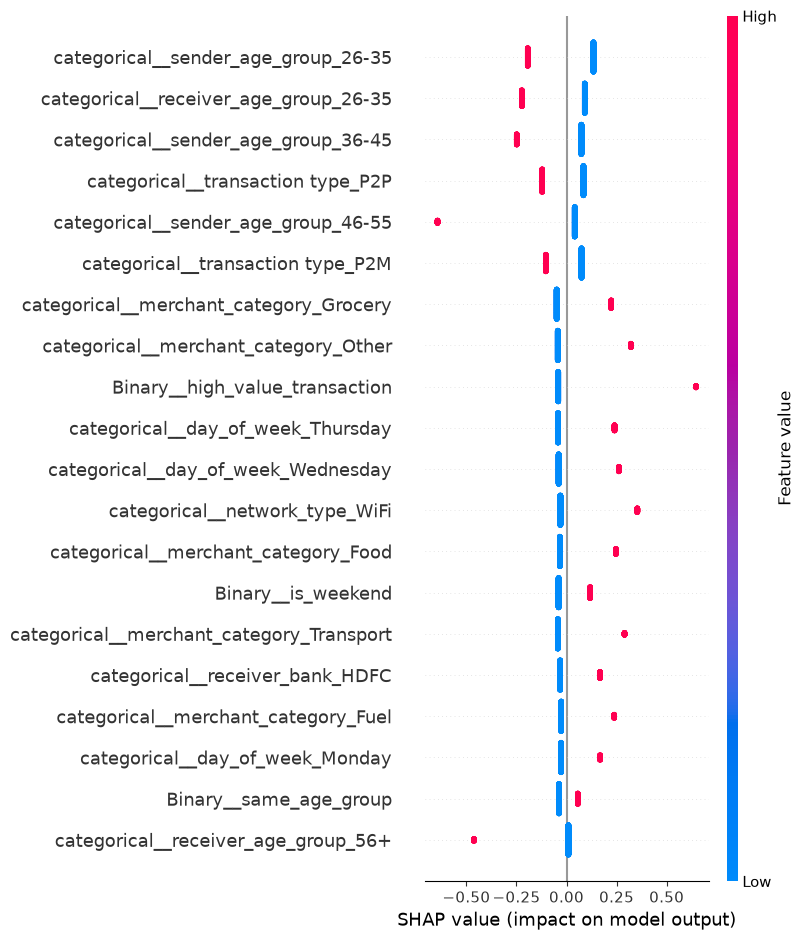

In [443]:
shap.summary_plot(
    shap_values.values,
    X_explain,
    feature_names = feature_names
)

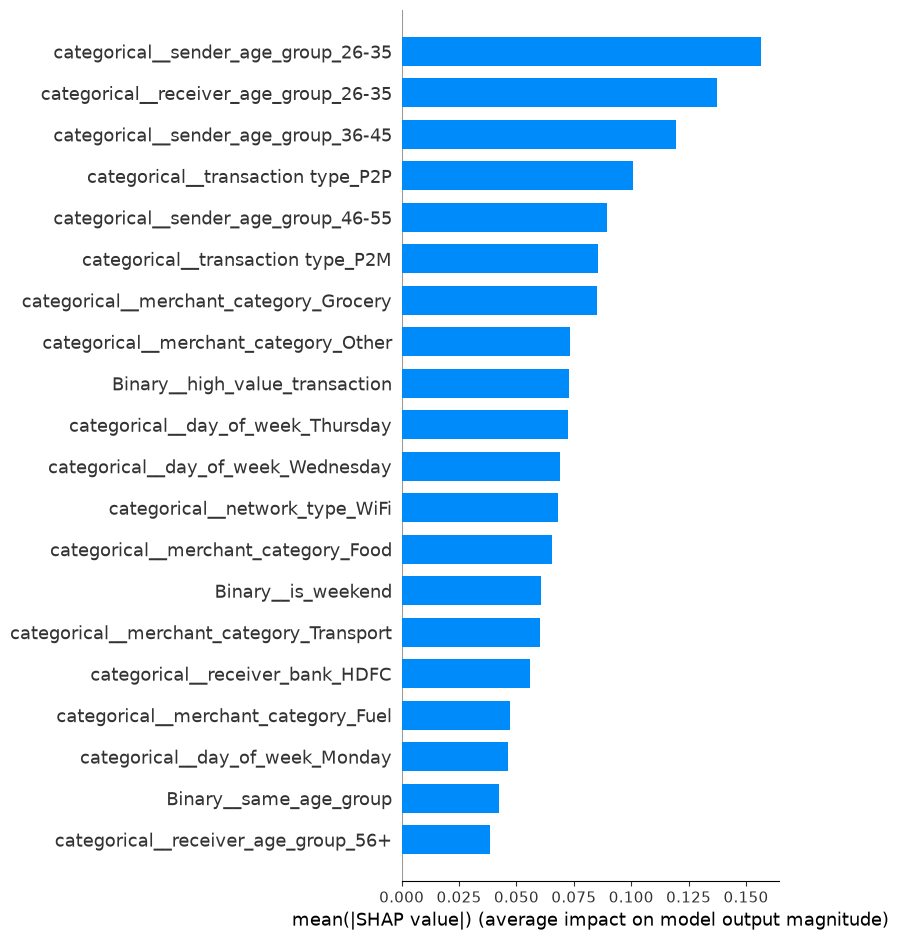

In [444]:
shap.summary_plot(
    shap_values.values,
    X_explain,
    feature_names = feature_names,
    plot_type = "bar"
)

### local SHAP explainability. Instead of explaining the model overall, we're going to pick one specific transaction with a high fraud score and ask Why did our Logistic Regression give this transaction a high fraud score

In [445]:
fraud_scores = best_log_model.predict_proba(X_explain)[:, 1]

highest_index  = fraud_scores.argmax()
print('Posititon', highest_index)
print("fraud_score", fraud_scores[highest_index])

Posititon 462
fraud_score 0.7951432146314745


In [446]:
actual_class = y_test.iloc[highest_index]
print('Actual class:', actual_class)

Actual class: 0


In [447]:
transaction_shap = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values.values[highest_index],
    "feature_value": X_explain.iloc[highest_index].values
})


transaction_shap["importance"] = transaction_shap["shap_value"].abs()

transaction_shap.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,shap_value,feature_value,importance
60,Binary__high_value_transaction,0.646390,1.000000,0.646390
8,categorical__merchant_category_Other,0.320976,1.000000,0.320976
53,categorical__day_of_week_Wednesday,0.261174,1.000000,0.261174
16,categorical__receiver_age_group_26-35,-0.222980,1.000000,0.222980
24,categorical__sender_state_Rajasthan,0.172791,1.000000,0.172791
36,categorical__receiver_bank_HDFC,0.167239,1.000000,0.167239
30,categorical__sender_bank_ICICI,0.163431,1.000000,0.163431
12,categorical__sender_age_group_26-35,0.134441,0.000000,0.134441
0,categorical__transaction type_P2M,-0.103572,1.000000,0.103572
1,categorical__transaction type_P2P,0.084493,0.000000,0.084493


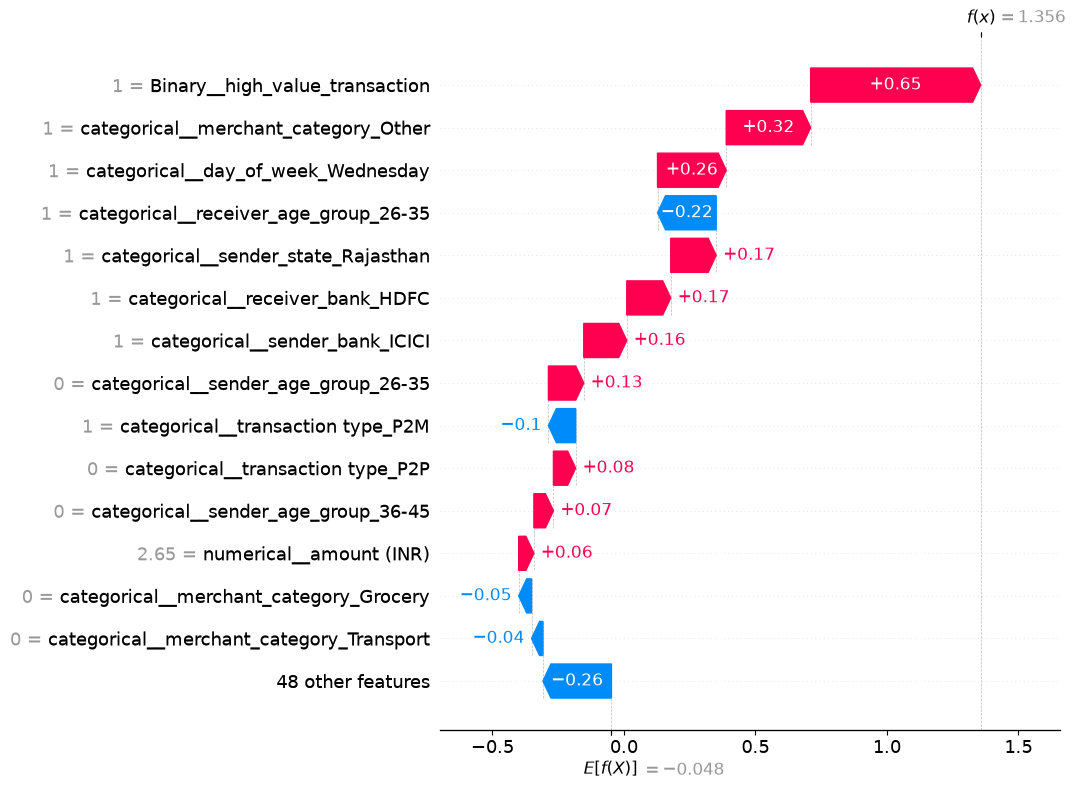

In [448]:
shap.plots.waterfall(
    shap_values[highest_index],
    max_display=15
)

# Conclusion

## Final Model Evaluation and Conclusion

### Models Evaluated
The following approaches were evaluated for UPI fraud detection:

- Logistic Regression with class weighting
- Random Forest
- XGBoost with `scale_pos_weight`
- Logistic Regression with SMOTE
- Random Forest with SMOTE
- XGBoost with SMOTE
- Hyperparameter-tuned Logistic Regression
- Threshold tuning

### Key Findings

The dataset is extremely imbalanced, with fraud transactions representing approximately 0.19% of all transactions.

Initial models achieved high overall accuracy in some cases because they predominantly predicted the majority genuine class. Therefore, accuracy alone was not considered an appropriate metric for evaluating fraud detection performance.

Metrics such as:

- Fraud Recall
- Fraud Precision
- F1-score
- PR-AUC
- ROC-AUC
- Confusion Matrix

were used to evaluate the models.

Class weighting improved fraud recall for Logistic Regression but resulted in a large number of false positives.

SMOTE was also evaluated to address class imbalance. However, oversampling did not produce a meaningful improvement in the model's ability to distinguish genuine and fraudulent transactions.

Random Forest and XGBoost also showed limited fraud discrimination despite imbalance-handling techniques.

Hyperparameter tuning was performed for Logistic Regression using Average Precision as the optimization metric. Threshold tuning was subsequently performed to study the trade-off between fraud recall and false positives.

### Final Model

Logistic Regression was retained as the final model because it provided a useful interpretable baseline and allowed detailed analysis of the factors influencing model predictions.

However, the final model showed weak discrimination between genuine and fraudulent transactions. The ROC-AUC remained close to 0.50 and PR-AUC remained very low, indicating that the available features contain limited predictive signal for identifying fraud reliably.

Therefore, the model should not be considered production-ready.

### Explainability

Model behavior was analyzed using:

- Logistic Regression coefficients
- Global SHAP feature importance
- SHAP beeswarm plots
- Local SHAP waterfall explanations

Features such as high-value transaction indicators, age groups, merchant categories, transaction types, network type, and day-of-week influenced model predictions.

A local SHAP analysis also demonstrated an important limitation of the model: a genuine transaction received a relatively high fraud score because several features collectively pushed the prediction toward fraud.

This illustrates why model explainability should be considered alongside predictive performance.

### Final Conclusion

The project demonstrates that handling class imbalance alone is not sufficient for building an effective fraud detection system.

Although techniques such as class weighting, SMOTE, threshold tuning, ensemble models, and hyperparameter optimization were evaluated, the available dataset did not provide enough discriminatory information to reliably separate fraud from genuine transactions.

Future improvements should therefore focus primarily on richer behavioral and historical features such as transaction velocity, customer spending deviation, device history, beneficiary history, account age, geographic anomalies, and historical fraud-risk indicators rather than relying only on further model tuning.

# Saving the Model

In [449]:
import os

os.makedirs("../models", exist_ok=True)

In [450]:
import joblib

joblib.dump(
    best_log_model,
    "../models/logistic_regression_model.pkl"
)

joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

['../models/preprocessor.pkl']

In [451]:
loaded_preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

loaded_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

In [452]:
sample_transaction = X_test.iloc[[0]]

sample_transaction

,transaction type,merchant_category,amount (INR),sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
115049,P2P,Food,244,26-35,26-35,Maharashtra,ICICI,HDFC,Android,4G,15,Saturday,1,0,0,1,0,0


In [453]:
sample_prepared = loaded_preprocessor.transform(
    sample_transaction
)

print(sample_prepared.shape)

(1, 62)


In [454]:
fraud_score = loaded_model.predict_proba(
    sample_prepared
)[:, 1]

print("Fraud score:", fraud_score[0])

Fraud score: 0.49670490028740877


e:\Projects\UPI Fraud detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [455]:
print("Actual class:", y_test.iloc[0])

Actual class: 0


In [456]:
threshold = 0.62

prediction = (
    fraud_score[0] >= threshold
).astype(int)

print("Fraud score:", fraud_score[0])
print("Threshold:", threshold)
print("Prediction:", prediction)
print("Actual:", y_test.iloc[0])

Fraud score: 0.49670490028740877
Threshold: 0.62
Prediction: 0
Actual: 0


In [457]:
final_threshold = 0.62

joblib.dump(
    final_threshold,
    "../models/final_threshold.pkl"
)

['../models/final_threshold.pkl']

In [458]:
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")
loaded_model = joblib.load("../models/logistic_regression_model.pkl")
loaded_threshold = joblib.load("../models/final_threshold.pkl")

In [459]:
sample_transaction = X_test.iloc[0].to_dict()

print(sample_transaction)

{'transaction type': 'P2P', 'merchant_category': 'Food', 'amount (INR)': 244, 'sender_age_group': '26-35', 'receiver_age_group': '26-35', 'sender_state': 'Maharashtra', 'sender_bank': 'ICICI', 'receiver_bank': 'HDFC', 'device_type': 'Android', 'network_type': '4G', 'transaction_hour': 15, 'day_of_week': 'Saturday', 'is_weekend': 1, 'night_transaction': 0, 'same_bank': 0, 'same_age_group': 1, 'high_value_transaction': 0, 'peak_hour': 0}


In [460]:
print(X_train.columns.tolist())

['transaction type', 'merchant_category', 'amount (INR)', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'transaction_hour', 'day_of_week', 'is_weekend', 'night_transaction', 'same_bank', 'same_age_group', 'high_value_transaction', 'peak_hour']


Correcting the preprocessor

In [461]:
print("Prepared training shape:")
print(X_train_prepared.shape)

print("\nFeatures expected by this preprocessor:")
print(preprocessor.feature_names_in_)

print("\nNumber of model coefficients:")
print(len(best_log_model.coef_[0]))

Prepared training shape:
(200000, 62)

Features expected by this preprocessor:
['transaction type' 'merchant_category' 'amount (INR)' 'sender_age_group'
 'receiver_age_group' 'sender_state' 'sender_bank' 'receiver_bank'
 'device_type' 'network_type' 'transaction_hour' 'day_of_week'
 'is_weekend' 'night_transaction' 'same_bank' 'same_age_group'
 'high_value_transaction' 'peak_hour']

Number of model coefficients:
62


In [462]:
print("\nFeatures expected by this preprocessor:")
print(preprocessor.feature_names_in_)


Features expected by this preprocessor:
['transaction type' 'merchant_category' 'amount (INR)' 'sender_age_group'
 'receiver_age_group' 'sender_state' 'sender_bank' 'receiver_bank'
 'device_type' 'network_type' 'transaction_hour' 'day_of_week'
 'is_weekend' 'night_transaction' 'same_bank' 'same_age_group'
 'high_value_transaction' 'peak_hour']


In [463]:
df.head()

,transaction type,merchant_category,amount (INR),sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,transaction_hour,day_of_week,is_weekend,night_transaction,same_bank,same_age_group,high_value_transaction,peak_hour
0,P2P,Entertainment,868,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,0,0,0,0,0
1,P2M,Grocery,1011,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,0,0,1,0,0
2,P2P,Grocery,477,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,0,0,0,0,0
3,P2P,Fuel,2784,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,0,0,1,0,1
4,P2P,Shopping,990,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,0,0,0,0,1


In [464]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_v1 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        ),
        (
            "numerical",
            StandardScaler(),
            numericl_columns
        ),
        (
            "Binary",
            "passthrough",
            binary_columns
        )
    ]
)

X_train_prepared_v1 = preprocessor_v1.fit_transform(X_train)
X_test_prepared_v1 = preprocessor_v1.transform(X_test)

In [465]:
print("Train prepared shape:", X_train_prepared_v1.shape)
print("Test prepared shape:", X_test_prepared_v1.shape)

print("\nRaw features expected:")
print(preprocessor_v1.feature_names_in_)

Train prepared shape: (200000, 62)
Test prepared shape: (50000, 62)

Raw features expected:
['transaction type' 'merchant_category' 'amount (INR)' 'sender_age_group'
 'receiver_age_group' 'sender_state' 'sender_bank' 'receiver_bank'
 'device_type' 'network_type' 'transaction_hour' 'day_of_week'
 'is_weekend' 'night_transaction' 'same_bank' 'same_age_group'
 'high_value_transaction' 'peak_hour']


In [466]:
from sklearn.linear_model import LogisticRegression

final_log_model_v1 = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

final_log_model_v1.fit(
    X_train_prepared_v1,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [467]:
print("Transformed features:",
      X_train_prepared_v1.shape[1])

print("Model coefficients:",
      len(final_log_model_v1.coef_[0]))

Transformed features: 62
Model coefficients: 62


In [468]:
import joblib

joblib.dump(
    preprocessor_v1,
    "../models/preprocessor.pkl"
)

joblib.dump(
    final_log_model_v1,
    "../models/logistic_regression_model1.pkl"
)

['../models/logistic_regression_model1.pkl']

In [469]:
loaded_preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

loaded_model = joblib.load(
    "../models/logistic_regression_model1.pkl"
)

print("Expected raw features:")
print(loaded_preprocessor.feature_names_in_)

print("\nNumber of model coefficients:")
print(len(loaded_model.coef_[0]))

Expected raw features:
['transaction type' 'merchant_category' 'amount (INR)' 'sender_age_group'
 'receiver_age_group' 'sender_state' 'sender_bank' 'receiver_bank'
 'device_type' 'network_type' 'transaction_hour' 'day_of_week'
 'is_weekend' 'night_transaction' 'same_bank' 'same_age_group'
 'high_value_transaction' 'peak_hour']

Number of model coefficients:
62


In [470]:
final_log_model_v1
X_train_prepared_v1
y_train

107369    0
127423    0
181287    0
215145    0
171409    0
         ..
207748    0
214701    0
5273      0
137462    0
225026    0
Name: fraud_flag, Length: 200000, dtype: int64

In [471]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_train_prob_v1 = cross_val_predict(
    final_log_model_v1,
    X_train_prepared_v1,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [472]:
print("Minimum:", y_train_prob_v1.min())
print("Maximum:", y_train_prob_v1.max())
print("Average:", y_train_prob_v1.mean())

Minimum: 0.09537719425163105
Maximum: 0.9221331864498791
Average: 0.47303208765075133


In [473]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.40, 0.71, 0.01)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_train_prob_v1 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    results.append([
        threshold,
        tn,
        fp,
        fn,
        tp,
        precision,
        recall,
        f1
    ])

threshold_results_v1 = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Precision",
        "Recall",
        "F1"
    ]
)

In [474]:
threshold_results_v1.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,TN,FP,FN,TP,Precision,Recall,F1
20,0.60,171364,28252,312,72,0.002542,0.187500,0.005016
25,0.65,186077,13539,350,34,0.002505,0.088542,0.004872
19,0.59,167468,32148,306,78,0.002420,0.203125,0.004784
26,0.66,188170,11446,356,28,0.002440,0.072917,0.004723
17,0.57,158580,41036,286,98,0.002382,0.255208,0.004721
18,0.58,163138,36478,297,87,0.002379,0.226562,0.004709
22,0.62,178168,21448,333,51,0.002372,0.132812,0.004661
21,0.61,174908,24708,326,58,0.002342,0.151042,0.004612
16,0.56,153769,45847,278,106,0.002307,0.276042,0.004575
23,0.63,181121,18495,341,43,0.002320,0.111979,0.004545


In [475]:
test_prob_v1 = final_log_model_v1.predict_proba(
    X_test_prepared_v1
)[:, 1]

for threshold in [0.50, 0.55, 0.57, 0.59, 0.60, 0.62]:

    pred = (test_prob_v1 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    print(f"\nThreshold: {threshold}")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    print(
        "Precision:",
        precision_score(y_test, pred, zero_division=0)
    )

    print(
        "Recall:",
        recall_score(y_test, pred, zero_division=0)
    )

    print(
        "F1:",
        f1_score(y_test, pred, zero_division=0)
    )


Threshold: 0.5
TN: 29741
FP: 20163
FN: 54
TP: 42
Precision: 0.0020786933927245733
Recall: 0.4375
F1: 0.0041377272055563765

Threshold: 0.55
TN: 37616
FP: 12288
FN: 76
TP: 20
Precision: 0.0016249593760155996
Recall: 0.20833333333333334
F1: 0.0032247662044501773

Threshold: 0.57
TN: 40262
FP: 9642
FN: 82
TP: 14
Precision: 0.0014498757249378626
Recall: 0.14583333333333334
F1: 0.002871205906480722

Threshold: 0.59
TN: 42562
FP: 7342
FN: 88
TP: 8
Precision: 0.0010884353741496598
Recall: 0.08333333333333333
F1: 0.0021488047273704003

Threshold: 0.6
TN: 43498
FP: 6406
FN: 89
TP: 7
Precision: 0.0010915328239513489
Recall: 0.07291666666666667
F1: 0.002150868028883085

Threshold: 0.62
TN: 45186
FP: 4718
FN: 90
TP: 6
Precision: 0.0012701100762066045
Recall: 0.0625
F1: 0.0024896265560165973


In [482]:
import joblib

final_threshold_v1 = 0.50

joblib.dump(
    final_threshold_v1,
    "../models/final_threshold1.pkl"
)

print("Final threshold saved:", final_threshold_v1)

Final threshold saved: 0.5


In [483]:
loaded_threshold = joblib.load(
    "../models/final_threshold1.pkl"
)

print("Loaded threshold:", loaded_threshold)

Loaded threshold: 0.5
